## Linear Regression
This notebook trains a linear regression model to determine which non-embedding features are most strongly associated with the derived engagement score.

Steps outlined

1. Load pre-built feature matrices (cols 768–796, excluding text embeddings)
2. Recompute continuous `engagement_score` from raw parquet via row indices
3. Apply min-max scaling uniformly across all 29 non-embedding features
4. Train `LinearRegression` and evaluate on val/test (MSE, R²)
5. Visualize coefficient importance bar chart and feature correlation heatmap

## Part 1:

In [31]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [32]:
X_train = np.load('../data/features/X_train.npy')  
X_val   = np.load('../data/features/X_val.npy')    
X_test  = np.load('../data/features/X_test.npy')   

y_train_class  = np.load('../data/features/y_train.npy')   
y_val_class    = np.load('../data/features/y_val.npy')
y_test_class  = np.load('../data/features/y_test.npy')

idx_train    = np.load('../data/features/idx_train.npy') 
idx_val      = np.load('../data/features/idx_val.npy')
idx_test     = np.load('../data/features/idx_test.npy')

with open('../data/features/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

In [33]:
print('X_train shape:', X_train.shape)
print('Meta keys:', list(meta.keys()))

X_train shape: (31063, 797)
Meta keys: ['feature_index', 'label_map', 'label_map_inv', 'numeric_cols', 'scaler', 'seed', 'n_train', 'n_val', 'n_test', 'total_features']


## Part 2:

In [39]:
## Compute the engagement_score 

df_raw = pd.read_parquet('../data/moltbook_posts_flat.parquet', engine="fastparquet")
print('Dataframe shape:', df_raw.shape)
print('Columns labels:', df_raw.columns.tolist())

Dataframe shape: (44376, 14)
Columns labels: ['annotation_row_id', 'topic_label', 'toxic_level', 'post_id', 'title', 'content', 'created_at', 'comment_count', 'upvotes', 'downvotes', 'url', 'submolt_id', 'submolt_name', 'submolt_display_name']


In [40]:
def compute_engagement_score(df):
    upvotes  = df['upvotes'].clip(lower=0).fillna(0)
    downvotes = df['downvotes'].clip(lower=0).fillna(0)
    comments  = df['comment_count'].clip(lower=0).fillna(0)
    return (np.log( 1+ upvotes ) + np.log( 1+ comments ) - 0.5 * np.log( 1+ downvotes ))

engagement_all = compute_engagement_score(df_raw).values

y_train_score = engagement_all[idx_train]
y_val_score  = engagement_all[idx_val]
y_test_score = engagement_all[idx_test]

## Part 3:

In [41]:
## slice out the non-embedding columns

TOPIC_COLS   = [f'topic_{c}' for c in 'ABCDEFGHI']         
TOXIC_COLS   = [f'toxic_{i}' for i in range(5)]              
NUMERIC_COLS = [
    'combined_word_count', 'sentence_count', 'title_char_len', 'content_char_len', 'has_url',
    'hour_of_day', 'day_of_week','vader_compound', 'tb_polarity', 'tb_subjectivity',
    'noun_count', 'pronoun_count', 'verb_count', 'adjective_count', 'adverb_count'
]

FEATURE_NAMES = TOPIC_COLS + TOXIC_COLS + NUMERIC_COLS   

X_train_no_emb = X_train[:, 768:]   # (31063, 29)
X_val_no_emb   = X_val[:, 768:]     # (6656,  29)
X_test_no_emb  = X_test[:, 768:]    # (6657,  29)

print('Non-embedding feature matrix shape (train):', X_train_no_emb.shape)
print('Feature names:', FEATURE_NAMES)

Non-embedding feature matrix shape (train): (31063, 29)
Feature names: ['topic_A', 'topic_B', 'topic_C', 'topic_D', 'topic_E', 'topic_F', 'topic_G', 'topic_H', 'topic_I', 'toxic_0', 'toxic_1', 'toxic_2', 'toxic_3', 'toxic_4', 'combined_word_count', 'sentence_count', 'title_char_len', 'content_char_len', 'has_url', 'hour_of_day', 'day_of_week', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'noun_count', 'pronoun_count', 'verb_count', 'adjective_count', 'adverb_count']


In [42]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_no_emb)
X_val_scaled   = scaler.transform(X_val_no_emb)
X_test_scaled  = scaler.transform(X_test_no_emb)

print('Scaled training set min/max:', X_train_scaled.min(), '/', X_train_scaled.max())
print('Scaled validation set min/max:', X_val_scaled.min(),   '/', X_val_scaled.max())

Scaled training set min/max: 0.0 / 1.0
Scaled validation set min/max: 0.0 / 1.0369893


## Part 4:

In [48]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train_scaled, y_train_score)

y_val_pred  = lr.predict(X_val_scaled)
y_test_pred = lr.predict(X_test_scaled)

print('Model trained. Intercept:', round(lr.intercept_, 4))

Model trained. Intercept: 8.5767


In [49]:
results = {
    'Validation': (y_val_score,  y_val_pred),
    'Test':       (y_test_score, y_test_pred),
}

print(f"{'Split':<12} {'MSE':>10} {'R²':>10}")
print('-' * 34)
for split, (y_true, y_pred) in results.items():
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{split:<12} {mse:>10.4f} {r2:>10.4f}")

Split               MSE         R²
----------------------------------
Validation       1.2851     0.4624
Test             1.3486     0.4430


In [53]:

coef_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'weight': lr.coef_
})


coef_df['abs_weight'] = coef_df['weight'].abs()
coef_df = coef_df.sort_values(by='abs_weight', ascending=False)


print(coef_df[['feature', 'weight']])

                feature     weight
26           verb_count  14.023425
15       sentence_count  -8.473134
25        pronoun_count   8.363052
17     content_char_len  -6.269746
20          day_of_week  -5.191597
16       title_char_len  -5.109015
24           noun_count   3.309991
19          hour_of_day  -2.861011
27      adjective_count  -1.146685
22          tb_polarity  -0.950147
11              toxic_2  -0.614209
14  combined_word_count   0.379616
13              toxic_4   0.316632
9               toxic_0   0.310452
18              has_url  -0.299234
8               topic_I  -0.243058
1               topic_B   0.217543
0               topic_A   0.206482
28         adverb_count  -0.180738
7               topic_H  -0.115108
23      tb_subjectivity  -0.108601
2               topic_C  -0.078493
12              toxic_3  -0.063331
10              toxic_1   0.050489
5               topic_F   0.048674
3               topic_D  -0.020289
21       vader_compound  -0.018333
6               topi

## Part 5:

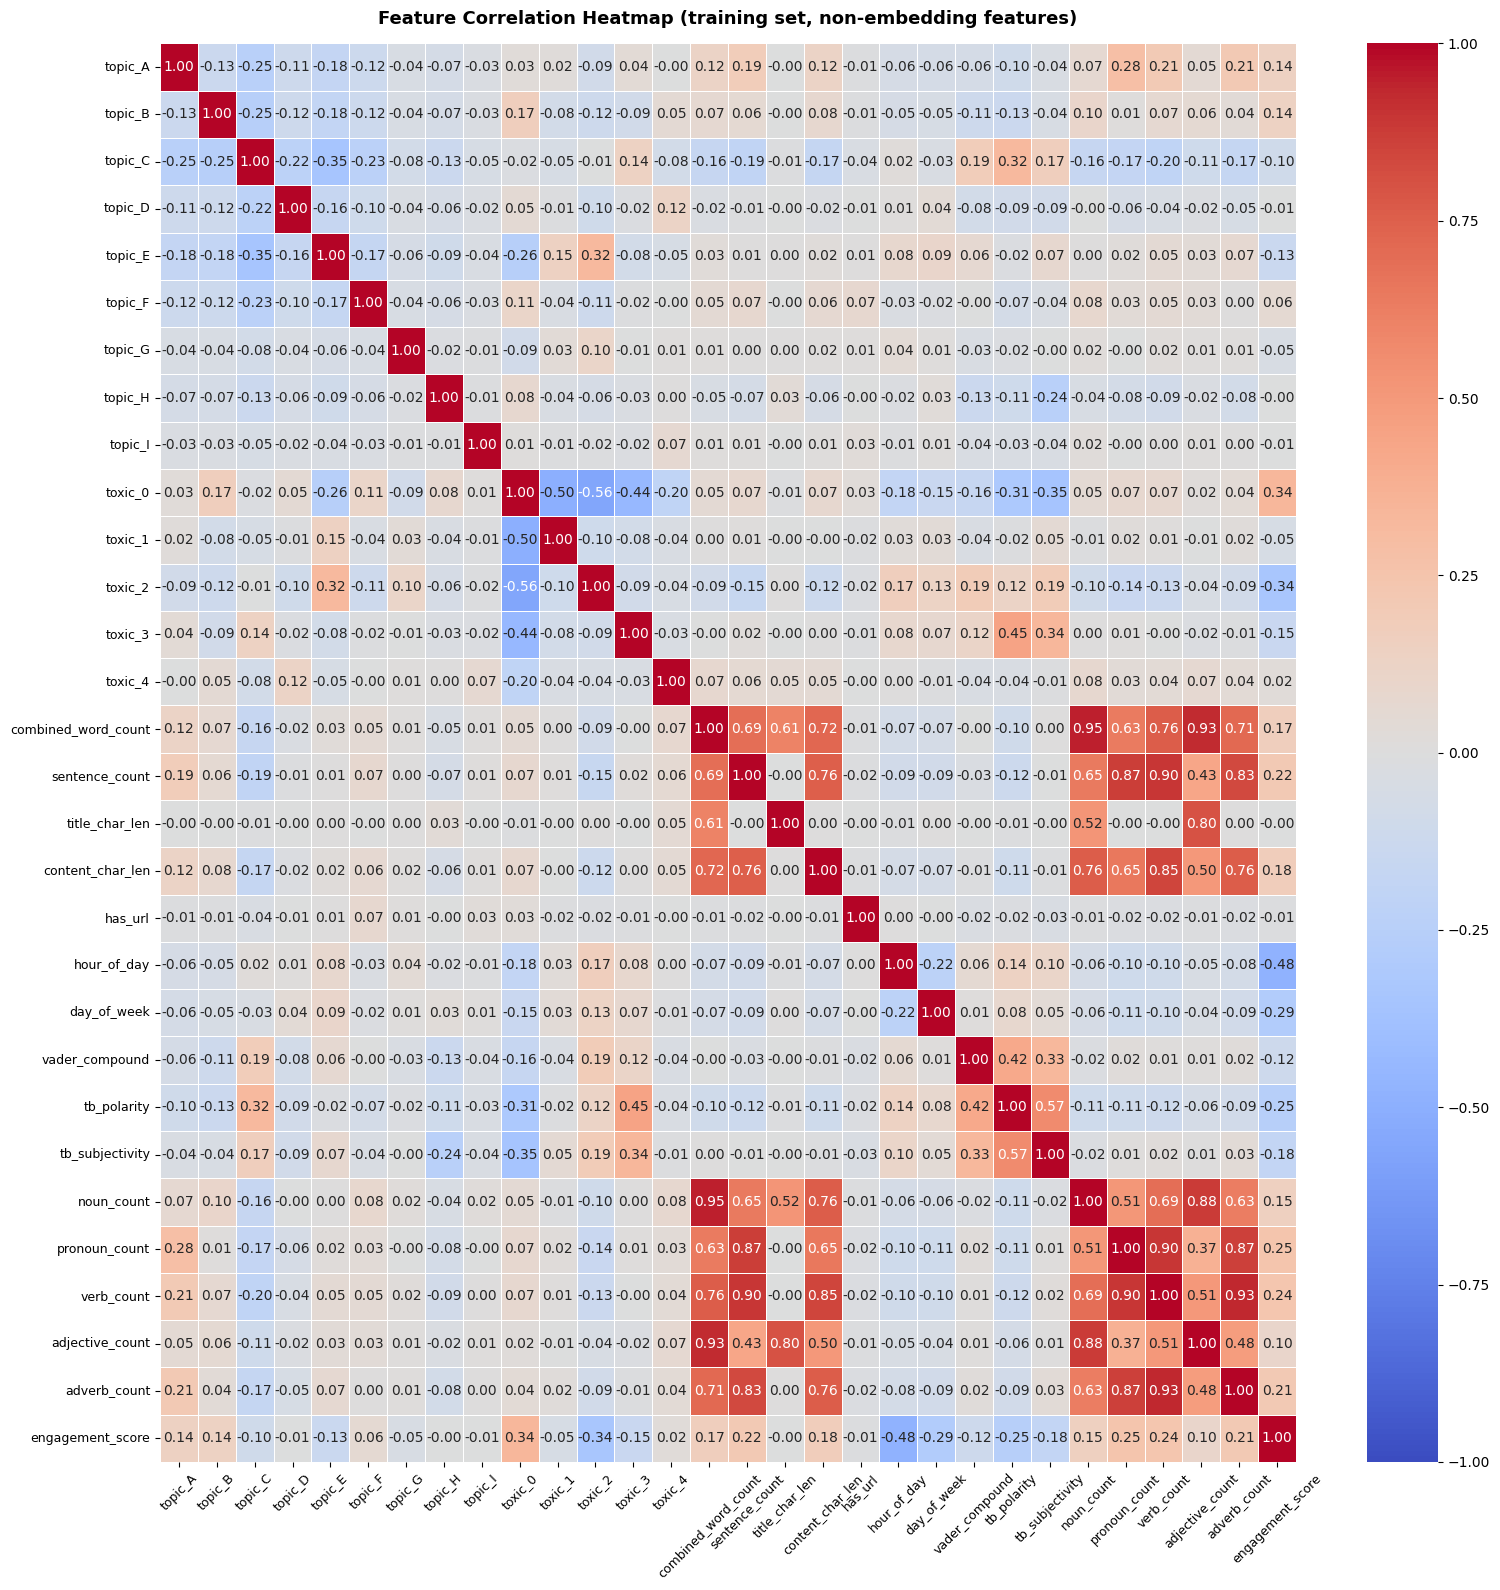

In [51]:
train_df = pd.DataFrame(X_train_no_emb, columns=FEATURE_NAMES)
train_df['engagement_score'] = y_train_score

corr = train_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 16))
mask = np.zeros_like(corr, dtype=bool)  

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 10},
)

ax.set_title('Feature Correlation Heatmap (training set, non-embedding features)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

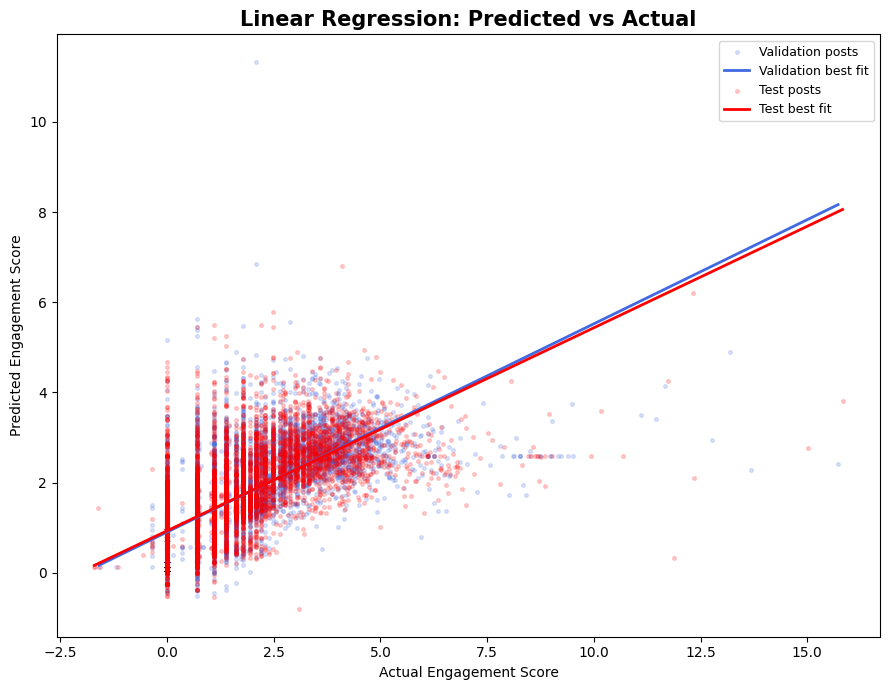

In [52]:
fig, ax = plt.subplots(figsize=(9, 7))

splits = [
    ('Validation', y_val_score,  y_val_pred,  'royalblue',  'royalblue'),
    ('Test',       y_test_score, y_test_pred, 'red', 'red'),
]

for split, y_true, y_pred, scatter_color, line_color in splits:
    ax.scatter(y_true, y_pred, alpha=0.18, s=7, color=scatter_color, label=f'{split} posts')

    m, b = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(y_true.min(), y_true.max(), 200)
    ax.plot(x_line, m * x_line + b, color=line_color, linewidth=2, label=f'{split} best fit')

ax.set_xlabel('Actual Engagement Score', fontsize=10)
ax.set_ylabel('Predicted Engagement Score', fontsize=10)
ax.set_title('Linear Regression: Predicted vs Actual', fontsize=15, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
